<a href="https://colab.research.google.com/github/alejandrobarrera-wq/Caso-de-estudio-sobre-incedios-forestales-en-Colombia/blob/main/Prevencion_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import glob
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/First 2026/colab Final"
casos_path = f"{BASE_PATH}/casos final.csv"
terra_path = f"{BASE_PATH}/terra"
suomi_path = f"{BASE_PATH}/suomi"
noa_path = f"{BASE_PATH}/noa"

firms_path = f"{BASE_PATH}/NASA_FIRMS_2010_2024.csv"
casos_path = f"{BASE_PATH}/casos final.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:


# Ruta principal
BASE_PATH = "/content/drive/MyDrive/First 2026/colab Final"

carpetas = ["terra", "suomi", "noa"]

for carpeta in carpetas:

    ruta = os.path.join(BASE_PATH, carpeta)

    archivos = glob.glob(os.path.join(ruta, "*.csv"))

    print(f"\nProcesando carpeta: {carpeta}")

    for archivo in archivos:

        df = pd.read_csv(archivo)

        # Renombrar según el satélite
        if carpeta == "terra":

            df.rename(columns={
                "brightness": "brightness"
            }, inplace=True)

        else:   # suomi y noa

            df.rename(columns={
                "bright_ti4": "brightness"
            }, inplace=True)

        # Guardar el archivo
        df.to_csv(archivo, index=False)

        print(f" {os.path.basename(archivo)} actualizado")


BASE_PATH = "/content/drive/MyDrive/First 2026/Colab final"

carpetas = ["terra", "suomi", "noa"]

for carpeta in carpetas:

    ruta = os.path.join(BASE_PATH, carpeta)

    # Buscar todos los CSV dentro de la carpeta
    archivos = glob.glob(os.path.join(ruta, "*.csv"))

    print(f"\nProcesando {carpeta}: {len(archivos)} archivos")

    for archivo in archivos:

        df = pd.read_csv(archivo)

        if carpeta == "terra":
            # MODIS
            df.rename(columns={
                "bright_t31": "brightness_aux"
            }, inplace=True)

        else:
            # VIIRS: Suomi y NOAA
            df.rename(columns={
                "bright_ti5": "brightness_aux"
            }, inplace=True)

        # Guardar el CSV actualizado
        df.to_csv(archivo, index=False)

        print("listo", os.path.basename(archivo))

print("\n Proceso terminado.")

print("\nTodos los archivos fueron modificados.")


Procesando carpeta: terra
 modis_2015_Colombia.csv actualizado
 modis_2011_Colombia.csv actualizado
 modis_2012_Colombia.csv actualizado
 modis_2013_Colombia.csv actualizado
 modis_2024_Colombia.csv actualizado
 modis_2019_Colombia.csv actualizado
 modis_2022_Colombia.csv actualizado
 modis_2016_Colombia.csv actualizado
 modis_2023_Colombia.csv actualizado
 modis_2020_Colombia.csv actualizado
 modis_2018_Colombia.csv actualizado
 modis_2014_Colombia.csv actualizado
 modis_2021_Colombia.csv actualizado
 modis_2017_Colombia.csv actualizado
 modis_2010_Colombia.csv actualizado

Procesando carpeta: suomi
 viirs-snpp_2014_Colombia.csv actualizado
 viirs-snpp_2020_Colombia.csv actualizado
 viirs-snpp_2016_Colombia.csv actualizado
 viirs-jpss1_2018_Colombia.csv actualizado
 viirs-snpp_2017_Colombia.csv actualizado
 viirs-snpp_2012_Colombia.csv actualizado
 viirs-snpp_2024_Colombia.csv actualizado
 viirs-jpss1_2019_Colombia.csv actualizado
 viirs-snpp_2022_Colombia.csv actualizado
 viirs-snpp

In [ ]:
#toma todos los CSV de una carpeta y los lee
def cargar_satelite(carpeta):

    archivos = sorted(glob.glob(os.path.join(carpeta, "*.csv")))

    print(f"Se encontraron {len(archivos)} archivos.\n")

    dataframes = []

    for archivo in archivos:

        print(f"Leyendo {os.path.basename(archivo)}")

        df = pd.read_csv(archivo)

        dataframes.append(df)

    satelite = pd.concat(dataframes, ignore_index=True)

    print("\nCarga finalizada.")
    print("Registros:", len(satelite))

    return satelite

In [ ]:
terra = cargar_satelite(terra_path)

terra.head()

Se encontraron 15 archivos.

Leyendo modis_2010_Colombia.csv
Leyendo modis_2011_Colombia.csv
Leyendo modis_2012_Colombia.csv
Leyendo modis_2013_Colombia.csv
Leyendo modis_2014_Colombia.csv
Leyendo modis_2015_Colombia.csv
Leyendo modis_2016_Colombia.csv
Leyendo modis_2017_Colombia.csv
Leyendo modis_2018_Colombia.csv
Leyendo modis_2019_Colombia.csv
Leyendo modis_2020_Colombia.csv
Leyendo modis_2021_Colombia.csv
Leyendo modis_2022_Colombia.csv
Leyendo modis_2023_Colombia.csv
Leyendo modis_2024_Colombia.csv

Carga finalizada.
Registros: 388963


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,3.3854,-72.0290,307.4,2.2,1.4,2010-01-01,341,Terra,MODIS,49,6.2,292.1,22.3,N,0
1,4.2056,-70.9787,305.7,2.8,1.6,2010-01-01,341,Terra,MODIS,65,6.2,292.9,28.0,N,0
2,3.3994,-72.0165,307.7,2.2,1.4,2010-01-01,341,Terra,MODIS,72,6.2,291.4,25.7,N,0
3,3.4764,-71.8424,318.7,2.3,1.5,2010-01-01,341,Terra,MODIS,97,6.2,294.6,52.1,N,0
4,3.5056,-71.8257,308.1,2.3,1.5,2010-01-01,341,Terra,MODIS,26,6.2,293.4,23.3,N,0


In [ ]:
suomi = cargar_satelite(suomi_path)
suomi.head



Se encontraron 13 archivos.

Leyendo viirs-jpss1_2018_Colombia.csv
Leyendo viirs-jpss1_2019_Colombia.csv
Leyendo viirs-snpp_2012_Colombia.csv
Leyendo viirs-snpp_2013_Colombia.csv
Leyendo viirs-snpp_2014_Colombia.csv
Leyendo viirs-snpp_2015_Colombia.csv
Leyendo viirs-snpp_2016_Colombia.csv
Leyendo viirs-snpp_2017_Colombia.csv
Leyendo viirs-snpp_2020_Colombia.csv
Leyendo viirs-snpp_2021_Colombia.csv
Leyendo viirs-snpp_2022_Colombia.csv
Leyendo viirs-snpp_2023_Colombia.csv
Leyendo viirs-snpp_2024_Colombia.csv

Carga finalizada.
Registros: 1289835


<bound method NDFrame.head of          latitude  longitude  brightness  scan  track    acq_date  acq_time  \
0         5.53516  -68.10213      367.00  0.73   0.76  2018-04-01       507   
1         5.53429  -68.09550      353.24  0.73   0.76  2018-04-01       507   
2         5.53342  -68.08887      342.59  0.73   0.76  2018-04-01       507   
3         5.52643  -68.08985      320.33  0.73   0.76  2018-04-01       507   
4         5.52904  -68.10974      313.52  0.73   0.76  2018-04-01       507   
...           ...        ...         ...   ...    ...         ...       ...   
1289830   6.04588  -71.57336      331.93  0.39   0.36  2024-12-31      1805   
1289831  10.79943  -74.33246      367.00  0.43   0.38  2024-12-31      1806   
1289832  10.80005  -74.32858      327.28  0.43   0.38  2024-12-31      1806   
1289833  10.80229  -74.33690      346.57  0.43   0.38  2024-12-31      1806   
1289834  10.80576  -74.33746      345.49  0.43   0.38  2024-12-31      1806   

        satellite instrument confidence  version  bright_ti5    frp daynight  \
0             N20      VIIRS          h        2      285.17  27.19        N   
1             N20      VIIRS          n        2      284.80  27.19        N   
2             N20      VIIRS          n        2      285.55   7.58        N   
3             N20      VIIRS          n        2      284.86   7.58        N   
4             N20      VIIRS          n        2      283.68  14.23        N   
...           ...        ...        ...      ...         ...    ...      ...   
1289830      SNPP      VIIRS          n        2      301.28   2.35        D   
1289831      SNPP      VIIRS          h        2      295.03  12.09        D   
1289832      SNPP      VIIRS          n        2      293.78   4.03        D   
1289833      SNPP      VIIRS          n        2      295.62   9.33        D   
1289834      SNPP      VIIRS          n        2      294.39   9.33        D   

         type  
0           0  
1           0  
2           0  
3           0  
4           0  
...       ...  
1289830     0  
1289831     0  
1289832     0  
1289833     0  
1289834     0  

[1289835 rows x 15 columns]>

In [ ]:
noa = cargar_satelite(noa_path)
noa.head

Se encontraron 7 archivos.

Leyendo viirs-jpss1_2018_Colombia.csv
Leyendo viirs-jpss1_2019_Colombia.csv
Leyendo viirs-jpss1_2020_Colombia.csv
Leyendo viirs-jpss1_2021_Colombia.csv
Leyendo viirs-jpss1_2022_Colombia.csv
Leyendo viirs-jpss1_2023_Colombia.csv
Leyendo viirs-jpss1_2024_Colombia.csv

Carga finalizada.
Registros: 712512


<bound method NDFrame.head of         latitude  longitude  brightness  scan  track    acq_date  acq_time  \
0        5.53516  -68.10213      367.00  0.73   0.76  2018-04-01       507   
1        5.53429  -68.09550      353.24  0.73   0.76  2018-04-01       507   
2        5.53342  -68.08887      342.59  0.73   0.76  2018-04-01       507   
3        5.52643  -68.08985      320.33  0.73   0.76  2018-04-01       507   
4        5.52904  -68.10974      313.52  0.73   0.76  2018-04-01       507   
...          ...        ...         ...   ...    ...         ...       ...   
712507   7.13820  -72.51012      331.97  0.57   0.43  2024-12-31      1828   
712508   8.20881  -72.47987      339.93  0.40   0.44  2024-12-31      1828   
712509  10.79888  -74.33350      336.46  0.50   0.41  2024-12-31      1829   
712510  10.80198  -74.33858      332.80  0.50   0.41  2024-12-31      1829   
712511  10.80635  -74.33456      331.16  0.50   0.41  2024-12-31      1829   

       satellite instrument confidence  version  bright_ti5    frp daynight  \
0            N20      VIIRS          h        2      285.17  27.19        N   
1            N20      VIIRS          n        2      284.80  27.19        N   
2            N20      VIIRS          n        2      285.55   7.58        N   
3            N20      VIIRS          n        2      284.86   7.58        N   
4            N20      VIIRS          n        2      283.68  14.23        N   
...          ...        ...        ...      ...         ...    ...      ...   
712507       N20      VIIRS          n        2      301.05   6.57        D   
712508       N20      VIIRS          n        2      295.48   3.30        D   
712509       N20      VIIRS          n        2      280.18   7.84        D   
712510       N20      VIIRS          n        2      285.33   6.11        D   
712511       N20      VIIRS          n        2      288.07   6.73        D   

        type  
0          0  
1          0  
2          0  
3          0  
4          0  
...      ...  
712507     0  
712508     0  
712509     0  
712510     0  
712511     0  

[712512 rows x 15 columns]>

In [ ]:
#con un volumen super bueno 388.963 + 1.374.898 + 712.512 2.476.373 registros
print(terra.shape)
print(suomi.shape)
print(noa.shape)
print(terra.columns)

(388963, 15)
(1289835, 15)
(712512, 15)
Index(['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date',
       'acq_time', 'satellite', 'instrument', 'confidence', 'version',
       'bright_t31', 'frp', 'daynight', 'type'],
      dtype='object')


In [ ]:
#verificar valores nulos
print("Terra")
print(terra.isnull().sum())

print("\nSuomi")
print(suomi.isnull().sum())

print("\nNOAA")
print(noa.isnull().sum())

Terra
latitude      0
longitude     0
brightness    0
scan          0
track         0
acq_date      0
acq_time      0
satellite     0
instrument    0
confidence    0
version       0
bright_t31    0
frp           0
daynight      0
type          0
dtype: int64

Suomi
latitude      0
longitude     0
brightness    0
scan          0
track         0
acq_date      0
acq_time      0
satellite     0
instrument    0
confidence    0
version       0
bright_ti5    0
frp           0
daynight      0
type          0
dtype: int64

NOAA
latitude      0
longitude     0
brightness    0
scan          0
track         0
acq_date      0
acq_time      0
satellite     0
instrument    0
confidence    0
version       0
bright_ti5    0
frp           0
daynight      0
type          0
dtype: int64


In [ ]:
print("Duplicados Terra:", terra.duplicated().sum())

print("Duplicados Suomi:", suomi.duplicated().sum())

print("Duplicados NOAA:", noa.duplicated().sum())

Duplicados Terra: 0
Duplicados Suomi: 0
Duplicados NOAA: 0


In [ ]:
#unios los datasets
firms = pd.concat(
    [terra, suomi, noa],
    ignore_index=True,
    # este parametro sort y false matienen el orden entre las columnassort=False
)

print("Duplicados firms:", firms.duplicated().sum())

# Eliminar registros completamente duplicados, porque puede que al unir la informacion de dos o tres sistemas satelitales se repitan incendios que al fin y al cabo ps no hacemos nada teniendo un moton de lo mismo
firms = firms.drop_duplicates().reset_index(drop=True)

print("Dataset maestro limpio:", firms.shape)
print("Duplicados restantes:", firms.duplicated().sum())

Duplicados firms: 152238
Dataset maestro limpio: (2239072, 16)
Duplicados restantes: 0


In [ ]:

print("\nNulos:")
print(firms.isnull().sum())
print("\nSatélites:")
print(firms["satellite"].value_counts())


Nulos:
latitude            0
longitude           0
brightness          0
scan                0
track               0
acq_date            0
acq_time            0
satellite           0
instrument          0
confidence          0
version             0
bright_t31    1850109
frp                 0
daynight            0
type                0
bright_ti5     388963
dtype: int64

Satélites:
satellite
SNPP     1137597
N20       712512
Aqua      254472
Terra     134491
Name: count, dtype: int64


In [ ]:
print(firms.shape)

firms.head()

(2239072, 16)


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,bright_ti5
0,3.3854,-72.0290,307.4,2.2,1.4,2010-01-01,341,Terra,MODIS,49,6.2,292.1,22.3,N,0,NaN
1,4.2056,-70.9787,305.7,2.8,1.6,2010-01-01,341,Terra,MODIS,65,6.2,292.9,28.0,N,0,NaN
2,3.3994,-72.0165,307.7,2.2,1.4,2010-01-01,341,Terra,MODIS,72,6.2,291.4,25.7,N,0,NaN
3,3.4764,-71.8424,318.7,2.3,1.5,2010-01-01,341,Terra,MODIS,97,6.2,294.6,52.1,N,0,NaN
4,3.5056,-71.8257,308.1,2.3,1.5,2010-01-01,341,Terra,MODIS,26,6.2,293.4,23.3,N,0,NaN


In [ ]:
carpeta = "/content/drive/MyDrive/First 2026/colab Final/suomi"

archivos = glob.glob(os.path.join(carpeta, "*.csv"))

print(f"Se encontraron {len(archivos)} archivos.\n")

for archivo in archivos:

    df = pd.read_csv(archivo)

    # Cambiar el valor de la columna satellite
    df["satellite"] = df["satellite"].replace("N", "SNPP")

    # Guardar el mismo archivo
    df.to_csv(archivo, index=False)

    print(f" {os.path.basename(archivo)} actualizado")

print("\nProceso finalizado;)")

firms.to_csv("NASA_FIRMS_2010_2024.csv", index=False)

Se encontraron 13 archivos.

 viirs-snpp_2014_Colombia.csv actualizado
 viirs-snpp_2020_Colombia.csv actualizado
 viirs-snpp_2016_Colombia.csv actualizado
 viirs-jpss1_2018_Colombia.csv actualizado
 viirs-snpp_2017_Colombia.csv actualizado
 viirs-snpp_2012_Colombia.csv actualizado
 viirs-snpp_2024_Colombia.csv actualizado
 viirs-jpss1_2019_Colombia.csv actualizado
 viirs-snpp_2022_Colombia.csv actualizado
 viirs-snpp_2023_Colombia.csv actualizado
 viirs-snpp_2021_Colombia.csv actualizado
 viirs-snpp_2013_Colombia.csv actualizado
 viirs-snpp_2015_Colombia.csv actualizado

Proceso finalizado;)


In [ ]:
print(firms.shape)

print(firms["satellite"].value_counts())

print(firms["satellite"].unique())


(2239072, 16)
satellite
SNPP     1137597
N20       712512
Aqua      254472
Terra     134491
Name: count, dtype: int64
['Terra' 'Aqua' 'N20' 'SNPP']


In [ ]:
firms.to_csv("NASA_FIRMS_2010_2024.csv", index=False)
from google.colab import files

files.download("NASA_FIRMS_2010_2024.csv")
#Ahora la columna de brightness quedo unificada con la bright ti4, ya que ambas son las principales son las principales bandas de deteccio,

KeyboardInterrupt: 

In [ ]:
print(terra.columns.tolist())
print(suomi.columns.tolist())
print(noa.columns.tolist())

['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_t31', 'frp', 'daynight', 'type']
['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight', 'type']
['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight', 'type']


In [ ]:

import matplotlib.pyplot as plt

# Cargar inventario procesado
casos = pd.read_csv(
    "/content/drive/MyDrive/First 2026/colab Final/casos_final_procesado.csv"
)

print("Dimensiones:", casos.shape)

display(casos.head())

Dimensiones: (14985, 8)


,AÑO,FECHA,DEPARTAMENTO,MUNICIPIO,EVENTO,TIPO DE ECOSISTEMA,COORDENADAS,COMENTARIOS
0,2025.0,2025-01-01,CESAR,EL PASO,INCENDIO FORESTAL,Vegetación secundaria,"9.2700, -73.5200","CDGRD CESAR INFORMA, MUNICIPIO: EL PASO - ZONA..."
1,2025.0,2025-01-01,NORTE DE SANTANDER,PAMPLONA,INCENDIO FORESTAL,Vegetación secundaria,"8.0750, -72.8150",CDGRD NORTE DE SANTANDER INFORMA: MUNICIPIO: P...
2,2025.0,2025-01-01,ARAUCA,TAME,INCENDIO FORESTAL,Otros / No determinado,"6.5800, -70.9100",INCENDIO FORESTAL REPORTADO EN BASE DE DATOS D...
3,2025.0,2025-01-01,CASANARE,YOPAL,INCENDIO FORESTAL,Otros / No determinado,"5.2850, -71.5050",INCENDIO FORESTAL REPORTADO EN BASE DE DATOS D...
4,2025.0,2025-01-01,VICHADA,PUERTO CARREÑO,INCENDIO FORESTAL,Pastizales,"4.4900, -69.5000",DNBC INFORMA: DEPARTAMENTO: VICHADA MUNICIPIO:...


In [ ]:
# Ver cuántos casos están clasificados como Otros / No determinado
otros = casos[
    casos["TIPO DE ECOSISTEMA"].str.contains(
        "otro|no determinado",
        case=False,
        na=False
    )
].copy()

print("Casos clasificados como Otros / No determinado:", len(otros))

print("\nPorcentaje del total:")
print(
    round(
        len(otros) / len(casos) * 100,
        2
    ),
    "%"
)
display(
    otros[
        [
            "FECHA",
            "DEPARTAMENTO",
            "MUNICIPIO",
            "TIPO DE ECOSISTEMA",
            "COORDENADAS",
            "COMENTARIOS"
        ]
    ].head(10)
)
print(
    otros["DEPARTAMENTO"]
    .value_counts()
    .head(10)
)

Casos clasificados como Otros / No determinado: 4662

Porcentaje del total:
31.11 %


,FECHA,DEPARTAMENTO,MUNICIPIO,TIPO DE ECOSISTEMA,COORDENADAS,COMENTARIOS
2,2025-01-01,ARAUCA,TAME,Otros / No determinado,"6.5800, -70.9100",INCENDIO FORESTAL REPORTADO EN BASE DE DATOS D...
3,2025-01-01,CASANARE,YOPAL,Otros / No determinado,"5.2850, -71.5050",INCENDIO FORESTAL REPORTADO EN BASE DE DATOS D...
5,2025-01-02,CASANARE,YOPAL,Otros / No determinado,"5.2950, -71.4950",INCENDIO FORESTAL REPORTADO EN BASE DE DATOS D...
6,2025-01-04,NORTE DE SANTANDER,ABREGO,Otros / No determinado,"8.1000, -72.7900",CDGRD NORTE DE SANTANDER INFORMA: MUNICIPIO: A...
10,2025-01-06,VICHADA,PUERTO CARREÑO,Otros / No determinado,"4.5200, -69.4700","CDGRD VICHADA INFORMA, MUNICIPIO: PUERTO CARRE..."
14,2025-01-06,VICHADA,PUERTO CARREÑO,Otros / No determinado,"4.5400, -69.5150",INCENDIO FORESTAL REPORTADO EN BASE DE DATOS D...
15,2025-01-07,BOYACA,TUTA,Otros / No determinado,"5.4600, -73.3100",INCENDIO FORESTAL REPORTADO EN BASE DE DATOS D...
21,2025-01-08,MAGDALENA,ALGARROBO,Otros / No determinado,"10.1900, -74.1800",INCENDIO FORESTAL REPORTADO EN BASE DE DATOS D...
23,2025-01-08,VICHADA,PUERTO CARREÑO,Otros / No determinado,"4.5000, -69.4700",INCENDIO FORESTAL REPORTADO EN BASE DE DATOS D...
25,2025-01-09,CASANARE,YOPAL,Otros / No determinado,"5.3100, -71.5250",INCENDIO FORESTAL REPORTADO EN BASE DE DATOS D...


DEPARTAMENTO
TOLIMA                526
CUNDINAMARCA          512
BOYACA                425
CASANARE              362
VALLE DEL CAUCA       358
HUILA                 276
ANTIOQUIA             264
META                  208
SANTANDER             202
NORTE DE SANTANDER    189
Name: count, dtype: int64


In [ ]:
print("Información del dataset:")
casos.info()

print("\nColumnas:")
print(casos.columns.tolist())

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14985 entries, 0 to 14984
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   AÑO                 14985 non-null  float64
 1   FECHA               14985 non-null  object 
 2   DEPARTAMENTO        14985 non-null  object 
 3   MUNICIPIO           14985 non-null  object 
 4   EVENTO              14985 non-null  object 
 5   TIPO DE ECOSISTEMA  14985 non-null  object 
 6   COORDENADAS         14985 non-null  object 
 7   COMENTARIOS         14979 non-null  object 
dtypes: float64(1), object(7)
memory usage: 936.7+ KB

Columnas:
['AÑO', 'FECHA', 'DEPARTAMENTO', 'MUNICIPIO', 'EVENTO', 'TIPO DE ECOSISTEMA', 'COORDENADAS', 'COMENTARIOS']


In [ ]:
print("Valores faltantes por columna:")
print(casos.isnull().sum())

Valores faltantes por columna:
AÑO                   0
FECHA                 0
DEPARTAMENTO          0
MUNICIPIO             0
EVENTO                0
TIPO DE ECOSISTEMA    0
COORDENADAS           0
COMENTARIOS           6
dtype: int64


In [ ]:
casos["FECHA"] = pd.to_datetime(
    casos["FECHA"],
    errors="coerce"
)

casos["AÑO"] = casos["FECHA"].dt.year

In [ ]:
incendios_anuales = (
    casos.groupby("AÑO")
    .size()
    .reset_index(name="INCENDIOS")
)

display(incendios_anuales)

,AÑO,INCENDIOS
0,2010,26
1,2012,1156
2,2013,1322
3,2014,1502
4,2015,2122
5,2016,1871
6,2017,1024
7,2018,1
8,2019,2453
9,2020,12


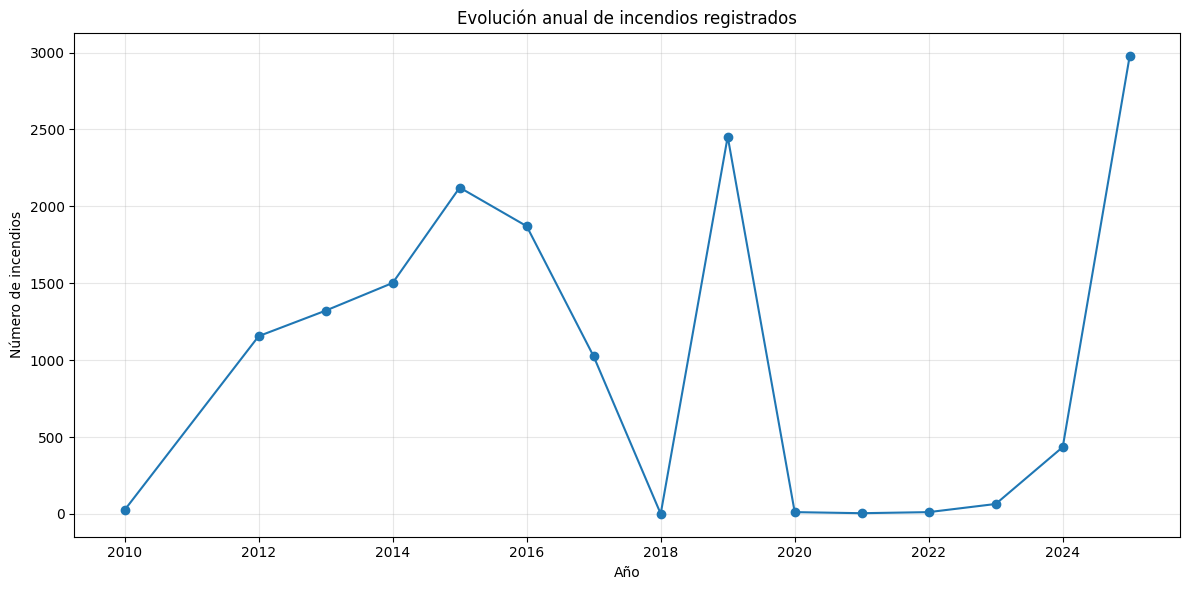

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    incendios_anuales["AÑO"],
    incendios_anuales["INCENDIOS"],
    marker="o"
)

plt.title("Evolución anual de incendios registrados")
plt.xlabel("Año")
plt.ylabel("Número de incendios")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

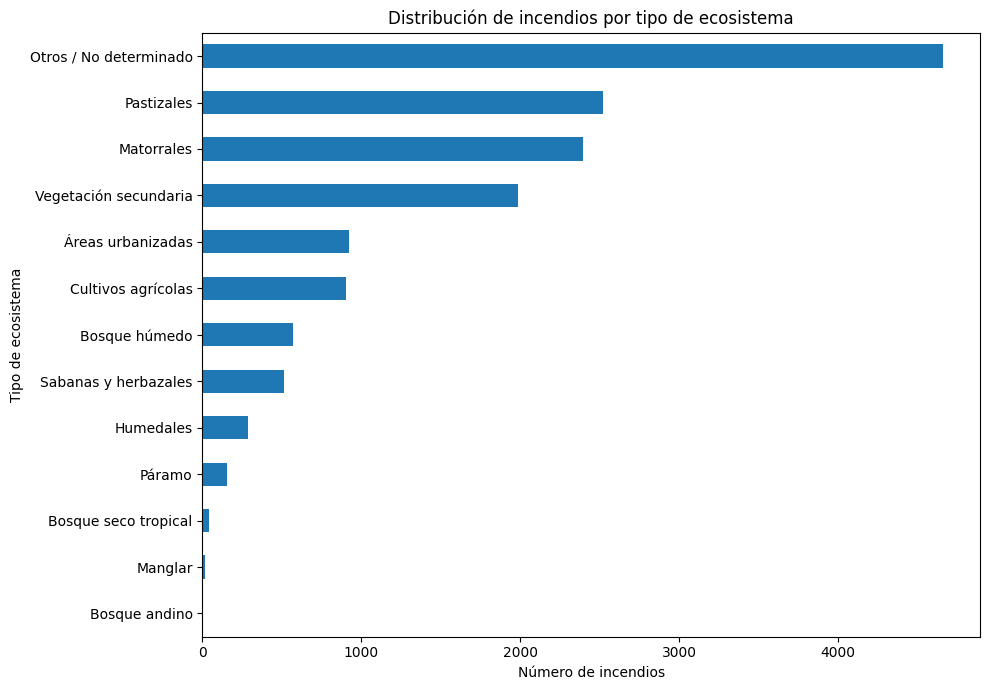

In [ ]:
ecosistemas = (
    casos["TIPO DE ECOSISTEMA"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))

ecosistemas.plot(
    kind="barh"
)

plt.title("Distribución de incendios por tipo de ecosistema")
plt.xlabel("Número de incendios")
plt.ylabel("Tipo de ecosistema")

plt.tight_layout()

plt.show()

In [ ]:
print(
    casos["COORDENADAS"].head(20)
)

0     9.2700, -73.5200
1     8.0750, -72.8150
2     6.5800, -70.9100
3     5.2850, -71.5050
4     4.4900, -69.5000
5     5.2950, -71.4950
6     8.1000, -72.7900
7     6.7050, -73.4850
8     4.5100, -69.4800
9     4.5150, -69.4750
10    4.5200, -69.4700
11    8.4250, -75.6300
12    9.3300, -75.1250
13    4.5350, -69.5200
14    4.5400, -69.5150
15    5.4600, -73.3100
16    5.2650, -71.5050
17    2.4700, -75.5000
18    1.9750, -71.4950
19    4.4800, -69.4900
Name: COORDENADAS, dtype: object


In [ ]:
# Separar latitud y longitud
casos[["LATITUD", "LONGITUD"]] = (
    casos["COORDENADAS"]
    .str.split(",", expand=True)
)

# Convertir a números
casos["LATITUD"] = pd.to_numeric(
    casos["LATITUD"],
    errors="coerce"
)

casos["LONGITUD"] = pd.to_numeric(
    casos["LONGITUD"],
    errors="coerce"
)

In [ ]:
print(
    casos[
        ["COORDENADAS", "LATITUD", "LONGITUD"]
    ].head(10)
)
print("Latitud mínima:", casos["LATITUD"].min())
print("Latitud máxima:", casos["LATITUD"].max())

print("Longitud mínima:", casos["LONGITUD"].min())
print("Longitud máxima:", casos["LONGITUD"].max())

        COORDENADAS  LATITUD  LONGITUD
0  9.2700, -73.5200    9.270   -73.520
1  8.0750, -72.8150    8.075   -72.815
2  6.5800, -70.9100    6.580   -70.910
3  5.2850, -71.5050    5.285   -71.505
4  4.4900, -69.5000    4.490   -69.500
5  5.2950, -71.4950    5.295   -71.495
6  8.1000, -72.7900    8.100   -72.790
7  6.7050, -73.4850    6.705   -73.485
8  4.5100, -69.4800    4.510   -69.480
9  4.5150, -69.4750    4.515   -69.475
Latitud mínima: -1.51
Latitud máxima: 11.54
Longitud mínima: -78.7768
Longitud máxima: -67.139


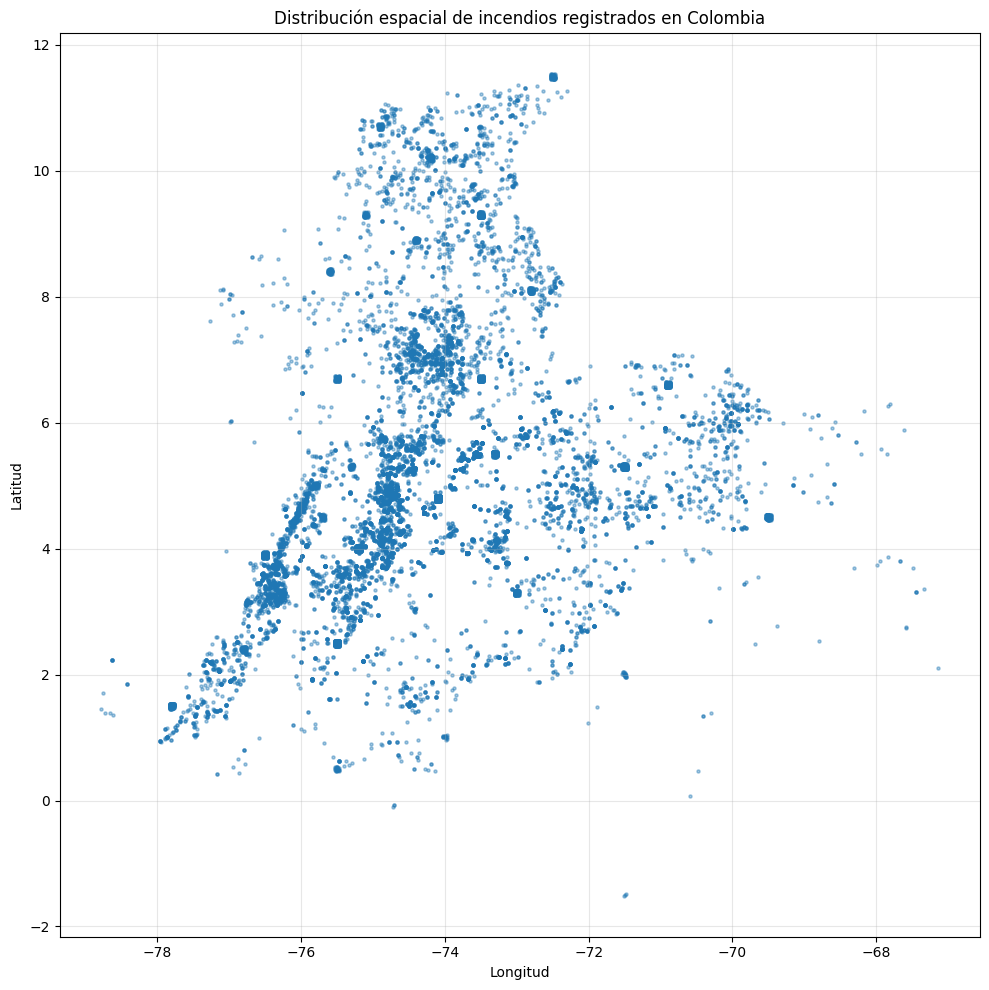

In [ ]:
plt.figure(figsize=(10, 10))

plt.scatter(
    casos["LONGITUD"],
    casos["LATITUD"],
    s=5,
    alpha=0.4
)

plt.title("Distribución espacial de incendios registrados en Colombia")
plt.xlabel("Longitud")
plt.ylabel("Latitud")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:

zip_path = "/content/drive/MyDrive/First 2026/colab Final/Mapa_Ecosistemas_Continentales_Costeros_Marinos_100K_2024.zip"
extract_path = "/content/drive/MyDrive/First 2026/colab final/MEC_2024"

In [ ]:
import zipfile
import os

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Descompresión completada.")

Descompresión completada.


In [ ]:
for root, dirs, files in os.walk(extract_path):
    for d in dirs:
        if d.endswith(".gdb"):
            print("GDB encontrada:")
            print(os.path.join(root, d))

GDB encontrada:
/content/drive/MyDrive/First 2026/colab final/MEC_2024/Mapa_Ecosistemas_Continentales_Costeros_Marinos_100K_2024/ECOSISTEMAS_MEC_122024.gdb


In [ ]:
# la ruta es
gdb_path = "/content/drive/MyDrive/First 2026/colab final/MEC_2024/Mapa_Ecosistemas_Continentales_Costeros_Marinos_100K_2024/ECOSISTEMAS_MEC_122024.gdb"

In [ ]:
!pip install fiona

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 29.8 MB/s eta 0:00:00


In [ ]:
import fiona

capas = fiona.listlayers(gdb_path)

print("Capas encontradas:")
for capa in capas:
    print("-", capa)

Capas encontradas:
- e_eccmc_100K_2024


In [ ]:
import geopandas as gpd

ecosistemas = gpd.read_file(
    gdb_path,
    layer="e_eccmc_100K_2024"
)

print("Capa cargada correctamente.")
print("Registros:", len(ecosistemas))
print("Columnas:")
print(ecosistemas.columns.tolist())


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


Capa cargada correctamente.
Registros: 460350
Columnas:
['tipo_ecos', 'gra_trans', 'gran_bioma', 'bioma_preliminar', 'bioma_IAvH', 'ecos_sintesis', 'ecos_general', 'u_sintesis', 'amb_acuatico', 'subsistema', 'nom_zh', 'origen', 'tipo_agua', 'clima', 'paisaje', 'relieve', 'suelos', 'amb_edafogenetico', 'desc_amb_edafogenetico', 'cob', 'sustrato', 'zona', 'temperatura', 'salinidad', 'provincia', 'eco_region', 'eco_zona', 'orig_marino', 'config_biotica', 'clasif_biotica', 'subclasif_biotica', 'grupo_biotico', 'sectores', 'area_ha', 'u_biotica', 'anfibios', 'aves', 'magnoliops', 'mamiferos', 'reptiles', 'no_anfibio', 'no_aves', 'no_magnoliops', 'no_mamiferos', 'no_reptiles', 'ruleid', 'override', 'Shape_Length', 'Shape_Area', 'geometry']


In [ ]:
print("CRS o sistema de referencia de coordenada del IDEAM:")
print(ecosistemas.crs)
print(ecosistemas.geom_type.value_counts())

CRS o sistema de referencia de coordenada del IDEAM:
EPSG:4686
MultiPolygon    460350
Name: count, dtype: int64


In [ ]:
print(ecosistemas.crs)
print(ecosistemas.columns.tolist())
print(ecosistemas.geom_type.value_counts())

EPSG:4686
['tipo_ecos', 'gra_trans', 'gran_bioma', 'bioma_preliminar', 'bioma_IAvH', 'ecos_sintesis', 'ecos_general', 'u_sintesis', 'amb_acuatico', 'subsistema', 'nom_zh', 'origen', 'tipo_agua', 'clima', 'paisaje', 'relieve', 'suelos', 'amb_edafogenetico', 'desc_amb_edafogenetico', 'cob', 'sustrato', 'zona', 'temperatura', 'salinidad', 'provincia', 'eco_region', 'eco_zona', 'orig_marino', 'config_biotica', 'clasif_biotica', 'subclasif_biotica', 'grupo_biotico', 'sectores', 'area_ha', 'u_biotica', 'anfibios', 'aves', 'magnoliops', 'mamiferos', 'reptiles', 'no_anfibio', 'no_aves', 'no_magnoliops', 'no_mamiferos', 'no_reptiles', 'ruleid', 'override', 'Shape_Length', 'Shape_Area', 'geometry']
MultiPolygon    460350
Name: count, dtype: int64


In [ ]:
print(casos[["COORDENADAS"]].head())

        COORDENADAS
0  9.2700, -73.5200
1  8.0750, -72.8150
2  6.5800, -70.9100
3  5.2850, -71.5050
4  4.4900, -69.5000


In [ ]:

from shapely.geometry import Point

casos["latitud"] = casos["COORDENADAS"].str.split(",").str[0].astype(float)
casos["longitud"] = casos["COORDENADAS"].str.split(",").str[1].astype(float)

casos_geo = gpd.GeoDataFrame(
    casos,
    geometry=gpd.points_from_xy(
        casos["longitud"],
        casos["latitud"]
    ),
    crs="EPSG:4326"
)

In [ ]:
# esta linea es la magia, hace que los puntos de los incendios del inventario de casos se transformen al mismo CRS que tiene la capa del IDEAM
casos_geo = casos_geo.to_crs(
    ecosistemas.crs
)

In [ ]:
resultado = gpd.sjoin(
    casos_geo,
    ecosistemas,
    how="left",
    predicate="within"
)
#quedaron con el mismo sistema de coordenadas que se maneja en Colombia
print(casos_geo.crs)
print(ecosistemas.crs)

EPSG:4686
EPSG:4686


In [ ]:
print("CRS incendios transformado:", casos_geo.crs)
print("CRS IDEAM:", ecosistemas.crs)

CRS incendios transformado: EPSG:4686
CRS IDEAM: EPSG:4686


In [ ]:
print(casos_geo.crs)
print(casos_geo.geometry.head())

EPSG:4686
0      POINT (-73.52 9.27)
1    POINT (-72.815 8.075)
2      POINT (-70.91 6.58)
3    POINT (-71.505 5.285)
4       POINT (-69.5 4.49)
Name: geometry, dtype: geometry


In [ ]:
resultado = gpd.sjoin(
    casos_geo,
    ecosistemas,
    how="left",
    predicate="within"
)

print("Casos originales:", len(casos_geo))
print("Filas después del sjoin:", len(resultado))

Casos originales: 14985
Filas después del sjoin: 14985


In [ ]:
print("Casos sin ecosistema asignado:",
      resultado["ecos_general"].isna().sum())

print("Casos con ecosistema asignado:",
      resultado["ecos_general"].notna().sum())

Casos sin ecosistema asignado: 0
Casos con ecosistema asignado: 14985


In [ ]:
# Seleccionar las columnas que queremos guardar
tabla_revision = resultado[[
    "FECHA",
    "DEPARTAMENTO",
    "MUNICIPIO",
    "COORDENADAS",
    "gran_bioma",
    "bioma_IAvH",
    "ecos_sintesis",
    "ecos_general",
    "clima",
    "paisaje",
    "relieve",
    "suelos"
]]

# Guardar como Excel
tabla_revision.to_excel(
    "/content/resultado_incendios_IDEAM.xlsx",
    index=False
)

print("Archivo guardado correctamente.")

Archivo guardado correctamente.


In [ ]:
resultado[
    [
        "FECHA",
        "DEPARTAMENTO",
        "MUNICIPIO",
        "COORDENADAS",
        "gran_bioma",
        "bioma_IAvH",
        "ecos_sintesis",
        "ecos_general"
    ]
].head(8)

,FECHA,DEPARTAMENTO,MUNICIPIO,COORDENADAS,gran_bioma,bioma_IAvH,ecos_sintesis,ecos_general
0,2025-01-01,CESAR,EL PASO,"9.2700, -73.5200",Zonobioma Humedo Tropical,Zonobioma Humedo Tropical Ariguaní - Cesar,Agroecosistema,Agroecosistema Ganadero
1,2025-01-01,NORTE DE SANTANDER,PAMPLONA,"8.0750, -72.8150",Zonobioma Humedo Tropical,Zonobioma Humedo Tropical Catatumbo,Agroecosistema,Agroecosistema Ganadero
2,2025-01-01,ARAUCA,TAME,"6.5800, -70.9100",Pedobioma del Zonobioma Humedo Tropical,Helobioma Arauca,Sabana,Sabana Inundable
3,2025-01-01,CASANARE,YOPAL,"5.2850, -71.5050",Pedobioma del Zonobioma Humedo Tropical,Helobioma Casanare,Transicional Transformado,Transicional Transformado
4,2025-01-01,VICHADA,PUERTO CARREÑO,"4.4900, -69.5000",Pedobioma del Zonobioma Humedo Tropical,Helobioma Altillanura,Bosque,Bosque Inundable Basal
5,2025-01-02,CASANARE,YOPAL,"5.2950, -71.4950",Pedobioma del Zonobioma Humedo Tropical,Helobioma Casanare,Bosque,Bosque Inundable Basal
6,2025-01-04,NORTE DE SANTANDER,ABREGO,"8.1000, -72.7900",Zonobioma Humedo Tropical,Zonobioma Humedo Tropical Catatumbo,Agroecosistema,Agroecosistema Ganadero
7,2025-01-05,SANTANDER,HATO,"6.7050, -73.4850",Orobioma del Zonobioma Humedo Tropical,Orobioma Subandino Cordillera Oriental Magdale...,Agroecosistema,Agroecosistema de Mosaico de Pastos y Espacios...


In [ ]:
resultado["ecos_general"].value_counts().head(80)

,count
ecos_general,
Agroecosistema Ganadero,3480
Transicional Transformado,1477
Vegetación Secundaria,1173
Agroecosistema de Mosaico de Cultivos y Pastos,1005
Agroecosistema de Mosaico de Pastos y Espacios Naturales,933
Sabana Inundable,699
"Agroecosistema de Mosaico de Cultivos, Pastos y Espacios Naturales",581
Agroecosistema Cañero,524
Bosque Basal Humedo,425


In [ ]:
resultado["gran_bioma"].value_counts()

,count
gran_bioma,
Zonobioma Humedo Tropical,3847
Orobioma del Zonobioma Humedo Tropical,3698
Pedobioma del Zonobioma Humedo Tropical,3511
Zonobioma Alternohigrico Tropical,2479
Orobioma Azonal del Zonobioma Humedo Tropical,1450


In [ ]:
#necesitamos investigarlo
resultado["ecos_sintesis"].value_counts().head(5)

,count
ecos_sintesis,
Agroecosistema,7484
Transicional Transformado,1489
Bosque,1395
Vegetacion Secundaria,1173
Sabana,1122


In [ ]:
otros = resultado[
    resultado["TIPO DE ECOSISTEMA"] == "Otros / No determinado"
]

print("Casos que antes eran Otros:",
      len(otros))

print(
    otros["ecos_general"]
    .value_counts()
    .head(20)
)

Casos que antes eran Otros: 4662
ecos_general
Agroecosistema Ganadero                                               1084
Transicional Transformado                                              442
Vegetación Secundaria                                                  357
Agroecosistema de Mosaico de Cultivos y Pastos                         334
Sabana Inundable                                                       322
Agroecosistema de Mosaico de Pastos y Espacios Naturales               263
Bosque Basal Humedo                                                    168
Agroecosistema Cañero                                                  168
Agroecosistema de Mosaico de Cultivos, Pastos y Espacios Naturales     161
Sabana Estacional                                                      158
Territorio Artificializado                                              83
Agroecosistema Arrocero                                                 78
Bosque Subandino Humedo                               

In [ ]:
print(resultado["ecos_general"].value_counts())
print(resultado["gran_bioma"].value_counts())

ecos_general
Agroecosistema Ganadero                                               3480
Transicional Transformado                                             1477
Vegetación Secundaria                                                 1173
Agroecosistema de Mosaico de Cultivos y Pastos                        1005
Agroecosistema de Mosaico de Pastos y Espacios Naturales               933
Sabana Inundable                                                       699
Agroecosistema de Mosaico de Cultivos, Pastos y Espacios Naturales     581
Agroecosistema Cañero                                                  524
Bosque Basal Humedo                                                    425
Sabana Estacional                                                      423
Agroecosistema Arrocero                                                413
Territorio Artificializado                                             362
Bosque Subandino Humedo                                                219
Subxerofitia

In [ ]:
print(casos[["COORDENADAS"]].head(5))

print("\nRango de latitudes:")
print(casos["latitud"].min(), casos["latitud"].max())

print("\nRango de longitudes:")
print(casos["longitud"].min(), casos["longitud"].max())

        COORDENADAS
0  9.2700, -73.5200
1  8.0750, -72.8150
2  6.5800, -70.9100
3  5.2850, -71.5050
4  4.4900, -69.5000

Rango de latitudes:
-1.51 11.54

Rango de longitudes:
-78.7768 -67.139


In [ ]:
print("Extensión de los incendios:")
print(casos_geo.total_bounds)

print("\nExtensión de la capa IDEAM:")
print(ecosistemas.total_bounds)

Extensión de los incendios:
[-78.7768  -1.51   -67.139   11.54  ]

Extensión de la capa IDEAM:
[-81.90591725  -4.22940646 -66.84721543  16.16249844]


In [ ]:
incendios_prueba = gpd.sjoin(
    casos_geo,
    ecosistemas[["geometry"]],
    how="left",
    predicate="within"
)

print("Total de incendios:", len(casos_geo))

print(
    "Puntos sin polígono IDEAM:",
    incendios_prueba["index_right"].isna().sum()
)

print(
    "Puntos dentro de un polígono IDEAM:",
    incendios_prueba["index_right"].notna().sum()
)
conteo = incendios_prueba.groupby(
    incendios_prueba.index
).size()

print("Incendios con una sola coincidencia:", (conteo == 1).sum())
print("Incendios con múltiples coincidencias:", (conteo > 1).sum())

Total de incendios: 14985
Puntos sin polígono IDEAM: 0
Puntos dentro de un polígono IDEAM: 14985
Incendios con una sola coincidencia: 14985
Incendios con múltiples coincidencias: 0


In [ ]:
resultado = gpd.sjoin(
    casos_geo,
    ecosistemas,
    how="left",
    predicate="within"
)

In [ ]:
print("Casos originales:", len(casos_geo))
print("Casos después del sjoin:", len(resultado))
print("Sin ecosistema:", resultado["ecos_general"].isna().sum())
print("Con ecosistema:", resultado["ecos_general"].notna().sum())

Casos originales: 14985
Casos después del sjoin: 14985
Sin ecosistema: 0
Con ecosistema: 14985


In [ ]:
print(resultado[[
    "COORDENADAS",
    "gran_bioma",
    "ecos_general"
]].head(8))

        COORDENADAS                               gran_bioma  \
0  9.2700, -73.5200                Zonobioma Humedo Tropical   
1  8.0750, -72.8150                Zonobioma Humedo Tropical   
2  6.5800, -70.9100  Pedobioma del Zonobioma Humedo Tropical   
3  5.2850, -71.5050  Pedobioma del Zonobioma Humedo Tropical   
4  4.4900, -69.5000  Pedobioma del Zonobioma Humedo Tropical   
5  5.2950, -71.4950  Pedobioma del Zonobioma Humedo Tropical   
6  8.1000, -72.7900                Zonobioma Humedo Tropical   
7  6.7050, -73.4850   Orobioma del Zonobioma Humedo Tropical   

                                        ecos_general  
0                            Agroecosistema Ganadero  
1                            Agroecosistema Ganadero  
2                                   Sabana Inundable  
3                          Transicional Transformado  
4                             Bosque Inundable Basal  
5                             Bosque Inundable Basal  
6                            Agroecosi

In [ ]:
print("Número de categorías de gran_bioma:")
print(resultado["gran_bioma"].nunique())

print("\nCategorías de gran_bioma:")
print(resultado["gran_bioma"].value_counts())

print("\nNúmero de categorías de ecos_general:")
print(resultado["ecos_general"].nunique())

print("\nCategorías de ecos_general:")
print(resultado["ecos_general"].value_counts())

Número de categorías de gran_bioma:
5

Categorías de gran_bioma:
gran_bioma
Zonobioma Humedo Tropical                        3847
Orobioma del Zonobioma Humedo Tropical           3698
Pedobioma del Zonobioma Humedo Tropical          3511
Zonobioma Alternohigrico Tropical                2479
Orobioma Azonal del Zonobioma Humedo Tropical    1450
Name: count, dtype: int64

Número de categorías de ecos_general:
57

Categorías de ecos_general:
ecos_general
Agroecosistema Ganadero                                               3480
Transicional Transformado                                             1477
Vegetación Secundaria                                                 1173
Agroecosistema de Mosaico de Cultivos y Pastos                        1005
Agroecosistema de Mosaico de Pastos y Espacios Naturales               933
Sabana Inundable                                                       699
Agroecosistema de Mosaico de Cultivos, Pastos y Espacios Naturales     581
Agroecosistema Cañe